<a href="https://colab.research.google.com/github/venkatalakshmiTammisetti/Blood-Link/blob/main/Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your 'kaggle.json' file downloaded from your Kaggle account settings:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 54.0MB/s]

Scanning directory structure...
Total scans found: 506
Executing image preprocessing algorithms...
Training Data Dimensions: (404, 224, 224, 3)
Validation Data Dimensions: (102, 224, 224, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Training Engine...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 291ms/step - accuracy: 0.5743 - loss: 0.7533 - val_accuracy: 0.7059 - val_loss: 0.5268
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7302 - loss: 0.5498 - val_accuracy: 0.7745 - val_loss: 0.4292
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7797 - loss: 0.4678 - val_accuracy: 0.8333 - val_loss: 0.3850
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8193 - loss: 0.4231 - val_accuracy: 0.8824 - val_loss: 0.3390
Epoch 5/15
13/13 


Training pipeline complete! Weights serialized to local storage as 'brain_tumor_model.h5'


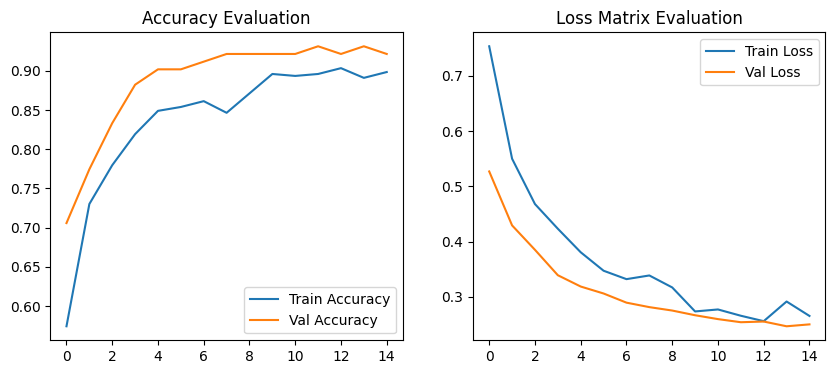

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

# =========================================================
# STEP 1: AUTHENTICATE KAGGLE AND DOWNLOAD DATASET
# =========================================================
print("Please upload your 'kaggle.json' file downloaded from your Kaggle account settings:")
uploaded = files.upload()

# Set up the Kaggle environment credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\nDownloading Brain Tumor MRI Dataset from Kaggle...")
# Downloading a popular, clean brain tumor binary classification dataset
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection
!unzip -q brain-mri-images-for-brain-tumor-detection.zip -d ./dataset

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Path to downloaded data folder inside Colab
INPUT_DIR = "./dataset"

def load_dataset_paths(base_dir):
    images = []
    labels = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):
                full_path = os.path.join(root, file)
                # Group data into classes based on folder naming conventions
                if 'no' in root.lower() or 'healthy' in root.lower():
                    images.append(full_path)
                    labels.append(0)  # 0: No Tumor
                elif 'yes' in root.lower() or 'tumor' in root.lower():
                    images.append(full_path)
                    labels.append(1)  # 1: Tumor Detected
    return images, labels

print("Scanning directory structure...")
image_paths, image_labels = load_dataset_paths(INPUT_DIR)
print(f"Total scans found: {len(image_paths)}")

# =========================================================
# STEP 2: CONTOUR-BASED PREPROCESSING (SKULL STRIPPING)
# =========================================================
def preprocess_mri(img_path, target_size=(224, 224)):
    image = cv2.imread(img_path)
    if image is None:
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Process contours to crop exactly to brain dimensions, discarding empty dark space
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]

    if len(cnts) > 0:
        c = max(cnts, key=cv2.contourArea)
        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])
        cropped_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]
    else:
        cropped_image = image

    # Final matrix transformation and normalization
    resized = cv2.resize(cropped_image, target_size)
    normalized = resized.astype("float32") / 255.0
    return normalized

print("Executing image preprocessing algorithms...")
X, y = [], []
for path, label in zip(image_paths, image_labels):
    processed_img = preprocess_mri(path)
    if processed_img is not None:
        X.append(processed_img)
        y.append(label)

X = np.array(X)
y = np.array(y)

# =========================================================
# STEP 3: TRAIN / VALIDATION SPLIT & AUGMENTATION
# =========================================================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Data Dimensions: {X_train.shape}")
print(f"Validation Data Dimensions: {X_val.shape}")

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
])

# =========================================================
# STEP 4: MODEL CONFIGURATION (TRANSFER LEARNING)
# =========================================================
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze ImageNet feature extractors

model = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Target probability node
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# =========================================================
# STEP 5: MODEL TRAINING & WEIGHT EXPORT
# =========================================================
print("\nStarting Training Engine...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

MODEL_NAME = "brain_tumor_model.h5"
model.save(MODEL_NAME)
print(f"\nTraining pipeline complete! Weights serialized to local storage as '{MODEL_NAME}'")

# Plotting metrics
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Evaluation')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Matrix Evaluation')
plt.show()


In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"lakshmi18105","key":"b15b2293947ba96fcf49d1779e496f5b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 110MB/s] 



In [ ]:
!mv "kaggle(1).json" kaggle.json

mv: cannot stat 'kaggle(1).json': No such file or directory


In [ ]:
import os
print(os.listdir())

['.config', 'kaggle (1).json', 'brain-mri-images-for-brain-tumor-detection.zip', 'sample_data']


In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import os

print(os.listdir())

['.config', 'kaggle (1).json', 'brain-mri-images-for-brain-tumor-detection.zip', 'sample_data']


In [ ]:
dataset_path = "brain_tumor_dataset"

print(os.listdir(dataset_path))

FileNotFoundError: [Errno 2] No such file or directory: 'brain_tumor_dataset'

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'kaggle (1).json', 'brain-mri-images-for-brain-tumor-detection.zip', 'sample_data']


In [ ]:
!unzip brain-mri-images-for-brain-tumor-detection.zip

Archive:  brain-mri-images-for-brain-tumor-detection.zip
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_dataset/no/27 no.jpg  
  inflating: brain_tumor_datase

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'kaggle (1).json', 'brain_tumor_dataset', 'yes', 'brain-mri-images-for-brain-tumor-detection.zip', 'no', 'sample_data']


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'kaggle (1).json', 'brain_tumor_dataset', 'yes', 'brain-mri-images-for-brain-tumor-detection.zip', 'no', 'sample_data']


In [ ]:
for folder in os.listdir('/content'):
    print(folder)

.config
kaggle (1).json
brain_tumor_dataset
yes
brain-mri-images-for-brain-tumor-detection.zip
no
sample_data


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
YES_PATH = "/content/yes"
NO_PATH = "/content/no"

yes_images = os.listdir(YES_PATH)
no_images = os.listdir(NO_PATH)

print("Tumor Images :", len(yes_images))
print("Healthy Images :", len(no_images))
print("Total Images :", len(yes_images) + len(no_images))

Tumor Images : 155
Healthy Images : 98
Total Images : 253


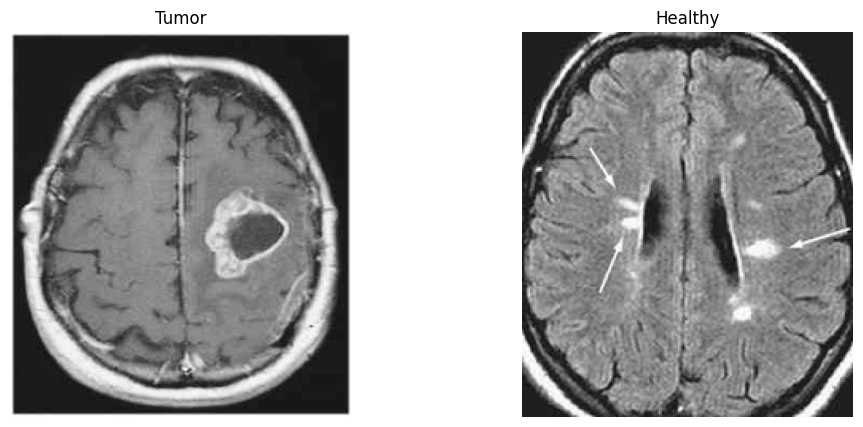

In [ ]:
plt.figure(figsize=(12,5))

# Tumor image
img = cv2.imread(os.path.join(YES_PATH, yes_images[0]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Tumor")
plt.axis("off")

# Healthy image
img = cv2.imread(os.path.join(NO_PATH, no_images[0]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,2)
plt.imshow(img)
plt.title("Healthy")
plt.axis("off")

plt.show()

In [ ]:
def crop_brain(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian Blur
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Thresholding
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(thresh.copy(),
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return image

    # Largest contour
    contour = max(contours, key=cv2.contourArea)

    # Bounding rectangle
    x, y, w, h = cv2.boundingRect(contour)

    # Crop brain
    cropped = image[y:y+h, x:x+w]

    return cropped

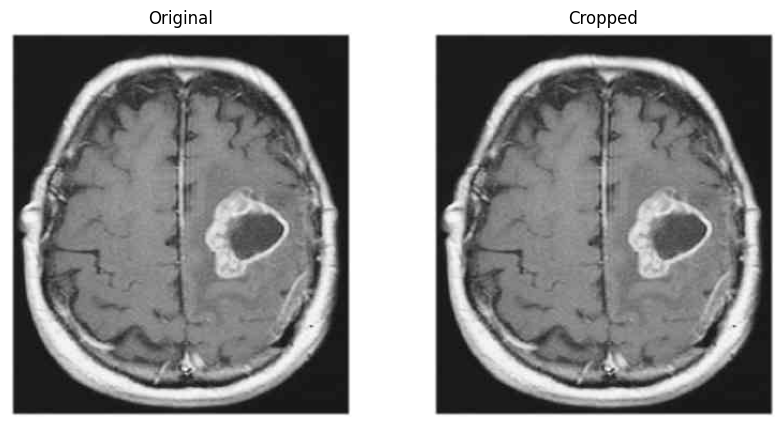

In [ ]:
sample = cv2.imread(os.path.join(YES_PATH, yes_images[0]))
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

cropped = crop_brain(sample)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cropped)
plt.title("Cropped")
plt.axis("off")

plt.show()

In [ ]:
IMG_SIZE = 224

def preprocess_image(image):

    image = crop_brain(image)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image.astype("float32") / 255.0

    return image

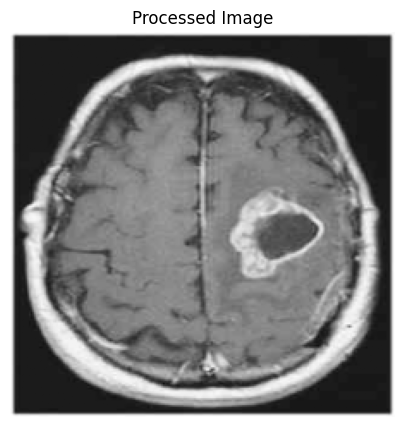

(224, 224, 3)
0.06666667 1.0


In [ ]:
processed = preprocess_image(sample)

plt.figure(figsize=(5,5))
plt.imshow(processed)
plt.title("Processed Image")
plt.axis("off")
plt.show()

print(processed.shape)
print(processed.min(), processed.max())

In [ ]:
X = []
y = []

In [ ]:
for image_name in yes_images:

    image_path = os.path.join(YES_PATH, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = preprocess_image(image)

    X.append(image)

    y.append(1)      # Tumor

In [ ]:
for image_name in no_images:

    image_path = os.path.join(NO_PATH, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = preprocess_image(image)

    X.append(image)

    y.append(0)      # Healthy

In [ ]:
X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Images Shape :", X.shape)
print("Labels Shape :", y.shape)

Images Shape : (253, 224, 224, 3)
Labels Shape : (253,)


In [ ]:
print("Tumor Images :", np.sum(y == 1))
print("Healthy Images :", np.sum(y == 0))

Tumor Images : 155
Healthy Images : 98


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (202, 224, 224, 3)
Testing Images : (51, 224, 224, 3)


In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input,
              outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "brain_tumor_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6155 - loss: 0.7749
Epoch 1: val_accuracy improved from None to 0.82353, saving model to brain_tumor_model.h5



Epoch 1: finished saving model to brain_tumor_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.6386 - loss: 0.7146 - val_accuracy: 0.8235 - val_loss: 0.4519
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.7195 - loss: 0.5416
Epoch 2: val_accuracy improved from 0.82353 to 0.88235, saving model to brain_tumor_model.h5



Epoch 2: finished saving model to brain_tumor_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.7129 - loss: 0.5306 - val_accuracy: 0.8824 - val_loss: 0.3882
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8148 - loss: 0.4673
Epoch 3: val_accuracy did not improve from 0.88235
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.8069 - loss: 0.4581 - val_accuracy: 0.8824 - val_loss: 0.3450
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8098 - loss: 0.4103
Epoch 4: val_accuracy improved from 0.88235 to 0.90196, saving model to brain_tumor_model.h5



Epoch 4: finished saving model to brain_tumor_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.8218 - loss: 0.4014 - val_accuracy: 0.9020 - val_loss: 0.3269
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8461 - loss: 0.3601
Epoch 5: val_accuracy did not improve from 0.90196
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - accuracy: 0.8317 - loss: 0.3811 - val_accuracy: 0.8824 - val_loss: 0.3152
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8631 - loss: 0.3191
Epoch 6: val_accuracy did not improve from 0.90196
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8267 - loss: 0.3425 - val_accuracy: 0.8824 - val_loss: 0.3038
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8852 - loss: 0.3460
Epoch 7: val_accuracy improved from 0.90196 to 0.94118, saving model to brain_tumor_model.h5



Epoch 7: finished saving model to brain_tumor_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - accuracy: 0.8564 - loss: 0.3486 - val_accuracy: 0.9412 - val_loss: 0.2851
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8378 - loss: 0.3350
Epoch 8: val_accuracy did not improve from 0.94118
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.8564 - loss: 0.3203 - val_accuracy: 0.9020 - val_loss: 0.2854
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8472 - loss: 0.3202
Epoch 9: val_accuracy did not improve from 0.94118
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.8762 - loss: 0.3129 - val_accuracy: 0.9216 - val_loss: 0.2741
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9164 - loss: 0.2593
Epoch 10: val_accuracy did not improve from 0.94118
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.9208 - loss: 0.2442 - val_accuracy: 0.9020 - val_loss: 0.2730


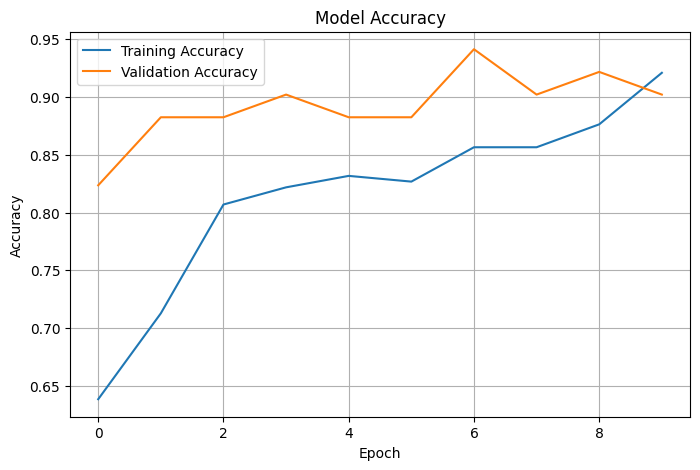

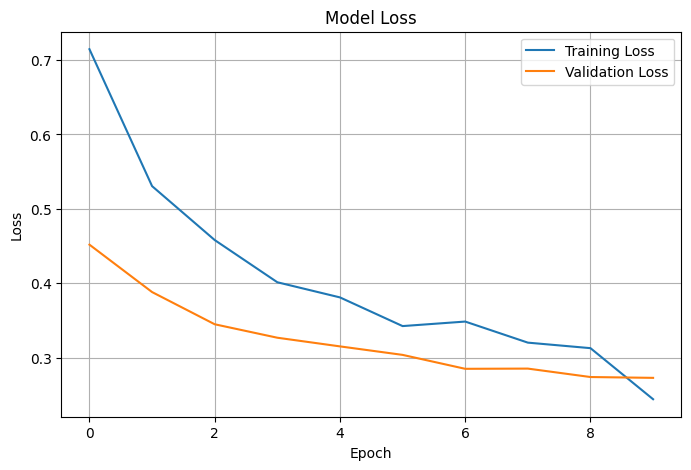

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9020 - loss: 0.2730
Test Accuracy: 90.20%


In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step


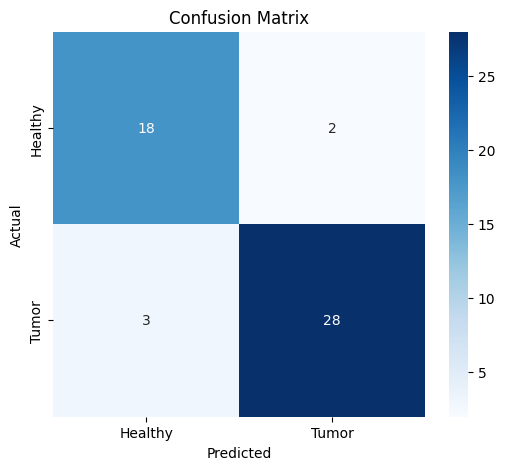

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Healthy','Tumor'],
            yticklabels=['Healthy','Tumor'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Healthy','Tumor']
))

              precision    recall  f1-score   support

     Healthy       0.86      0.90      0.88        20
       Tumor       0.93      0.90      0.92        31

    accuracy                           0.90        51
   macro avg       0.90      0.90      0.90        51
weighted avg       0.90      0.90      0.90        51



In [ ]:
model.save("brain_tumor_model.keras")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Y104.jpg to Y104.jpg


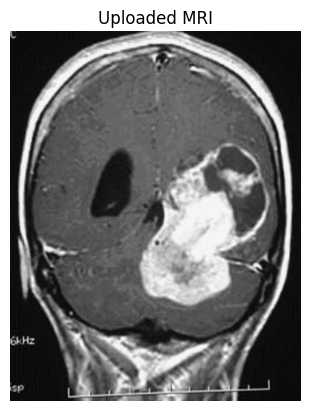

In [ ]:
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Uploaded MRI")
plt.axis("off")
plt.show()

In [ ]:
processed = preprocess_image(image)

processed = np.expand_dims(processed, axis=0)

In [ ]:
prediction = model.predict(processed)

confidence = prediction[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [ ]:
if confidence >= 0.5:
    print("🧠 Tumor Detected")
    print(f"Confidence: {confidence*100:.2f}%")
else:
    print("✅ Healthy Brain")a
    print(f"Confidence: {(1-confidence)*100:.2f}%")

🧠 Tumor Detected
Confidence: 99.86%


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 26 no.jpg to 26 no.jpg


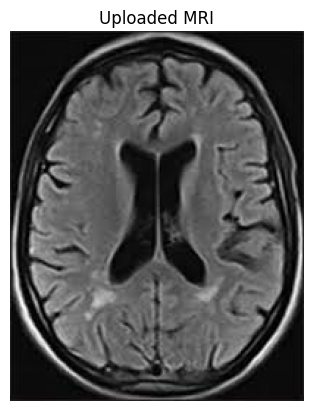

In [ ]:
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Uploaded MRI")
plt.axis("off")
plt.show()

In [ ]:
processed = preprocess_image(image)

processed = np.expand_dims(processed, axis=0)

In [ ]:
prediction = model.predict(processed)

confidence = prediction[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [ ]:
if confidence >= 0.5:
    print("🧠 Tumor Detected")
    print(f"Confidence: {confidence*100:.2f}%")
else:
    print("✅ Healthy Brain")
    print(f"Confidence: {(1-confidence)*100:.2f}%")

✅ Healthy Brain
Confidence: 96.50%


In [ ]:
# testing with google image
from google.colab import files

uploaded = files.upload()

Saving test.webp to test.webp


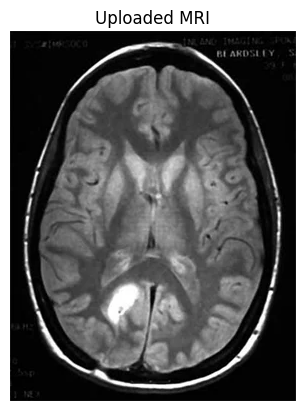

In [ ]:
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Uploaded MRI")
plt.axis("off")
plt.show()

In [ ]:
processed = preprocess_image(image)
processed = np.expand_dims(processed, axis=0)

In [ ]:
prediction = model.predict(processed)

confidence = prediction[0][0]

if confidence >= 0.5:
    print("🧠 Tumor Detected")
    print(f"Confidence: {confidence*100:.2f}%")
else:
    print("✅ Healthy Brain")
    print(f"Confidence: {(1-confidence)*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
🧠 Tumor Detected
Confidence: 82.14%
